# Information operations directed at Hong Kong: Part I

#### Introduction:
In 2019  a sequence of large-scale, anti-government protests took place in Hong Kong. Afterwards Twitter released a few data sets containing tweets that "disclosed a significant state-backed information operation focused on the situation in Hong Kong, specifically the protest movement and their calls for political change."

Some details about the protests can be found in the [wikipedia page on this](https://en.wikipedia.org/wiki/2019%E2%80%932020_Hong_Kong_protests). A brief summary is as follows: Hong Kong, a former British colony, after being handed over to China in 1997, is supposed to have an autonomous government for at least 50 years (until 2047), with its own separate judicial and financial systems. In April 2019, the Hong Kong government introduced an extradition law which would allow suspects to be extradited from Hong Kong to China for trial, bypassing Hong Kong's judicial system. The introduction of this law sparked a sequence of events that fundamentally changed the outlook of the city since then.

In this notebook we will take a quick look at these tweets, and perform some simple, unsupervised learning such as topic modelling to find out what topics the operation was focused on.

The data sets are rather large (> 5GB), so they will not be uploaded to Github. For the relevant blogpost and data sets, [click this link.](https://blog.twitter.com/en_us/topics/company/2019/information_operations_directed_at_Hong_Kong)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
#import calmap
import calplot
import warnings
import string
import jieba
import datetime as dt
import stopwordsiso

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

sns.set(style='white')
warnings.simplefilter(action='ignore')
pd.set_option('display.max_columns', None)

There are altogether 6 datasets, released by Twitter between 2019 and 2020.

In [2]:
df0 = pd.read_csv('2020/china_052020_tweets_csv_hashed.csv')
df1 = pd.read_csv('2019/china_082019_1_tweets_csv_hashed.csv')
df2 = pd.read_csv('2019/china_082019_2_tweets_csv_hashed.csv')
df3 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part1.csv')
df4 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part2.csv')
df5 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part3.csv')

df_lst = [df0, df1, df2, df3, df4, df5]

First we look at a few samples from the first two datasets, as well as printing out the columns (features). We also drop a few obviously irrelevant columns such as tweet url.

In [3]:
df0.head()   # df0 is the only dataframe in which userid and user_display_name are gibberish

,tweetid,userid,user_display_name,user_screen_name,user_reported_location,user_profile_description,user_profile_url,follower_count,following_count,account_creation_date,account_language,tweet_language,tweet_text,tweet_time,tweet_client_name,in_reply_to_userid,in_reply_to_tweetid,quoted_tweet_tweetid,is_retweet,retweet_userid,retweet_tweetid,latitude,longitude,quote_count,reply_count,like_count,retweet_count,hashtags,urls,user_mentions
0,1204942993939140608,bxJj6YkM0VJO9p7DCgvAr6cONFlVPqEs0xTI9GN4U=,bxJj6YkM0VJO9p7DCgvAr6cONFlVPqEs0xTI9GN4U=,bxJj6YkM0VJO9p7DCgvAr6cONFlVPqEs0xTI9GN4U=,NaN,NaN,NaN,2,20,2019-11-24,en,zh,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...,2019-12-12 01:56,Twitter Web App,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0,1,0,0,['郭文贵'],[],[]
1,1214065325760757760,LEN1D2bgSrc+NjYIjQK5o1Aa+5amIIR3cqeiclMc=,LEN1D2bgSrc+NjYIjQK5o1Aa+5amIIR3cqeiclMc=,LEN1D2bgSrc+NjYIjQK5o1Aa+5amIIR3cqeiclMc=,NaN,NaN,NaN,43,35,2019-12-10,zh-cn,und,https://t.co/hNm6nUAiE3,2020-01-06 06:05,Echofon,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0,0,0,0,[],['https://accounts.youtube.com/accounts/SetSID...,[]
2,1214500018503045122,LEN1D2bgSrc+NjYIjQK5o1Aa+5amIIR3cqeiclMc=,LEN1D2bgSrc+NjYIjQK5o1Aa+5amIIR3cqeiclMc=,LEN1D2bgSrc+NjYIjQK5o1Aa+5amIIR3cqeiclMc=,NaN,NaN,NaN,43,35,2019-12-10,zh-cn,und,https://t.co/UKuYfubjgh,2020-01-07 10:52,Echofon,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0,0,0,0,[],['https://accounts.youtube.com/accounts/SetSID...,[]
3,1213994655110483970,wUM3xcnXFbFPJHCO103DLLsCZfiGZbspt7rgmNnu2Q=,wUM3xcnXFbFPJHCO103DLLsCZfiGZbspt7rgmNnu2Q=,wUM3xcnXFbFPJHCO103DLLsCZfiGZbspt7rgmNnu2Q=,NaN,NaN,NaN,35,75,2020-01-03,en,und,https://t.co/KtpavahflW,2020-01-06 01:24,Echofon,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0,0,0,0,[],['https://accounts.youtube.com/accounts/SetSID...,[]
4,1191520301089116162,NnQLYb8S3Wth8rhVmxeLCChy0x3TWAt6kEpm0OxpM=,NnQLYb8S3Wth8rhVmxeLCChy0x3TWAt6kEpm0OxpM=,NnQLYb8S3Wth8rhVmxeLCChy0x3TWAt6kEpm0OxpM=,NaN,NaN,NaN,24,0,2019-10-23,en,ja,秋 https://t.co/36ISekYyC9,2019-11-05 00:59,Twitter Web App,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0,0,0,0,[],[],[]


In [4]:
df1.head()

,tweetid,userid,user_display_name,user_screen_name,user_reported_location,user_profile_description,user_profile_url,follower_count,following_count,account_creation_date,account_language,tweet_language,tweet_text,tweet_time,tweet_client_name,in_reply_to_userid,in_reply_to_tweetid,quoted_tweet_tweetid,is_retweet,retweet_userid,retweet_tweetid,latitude,longitude,quote_count,reply_count,like_count,retweet_count,hashtags,urls,user_mentions,poll_choices
0,235862198621184000,206027550,The Flecha,nessniven,Republic of Korea,When you see Jair Bolsonaro and his program of...,NaN,100847,31752,2010-10-22,en,NaN,VOU SEGUIR T-O-D-O-S QUE SEGUIREM O @OBobMarle...,2012-08-15 22:15,TweetDeck,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0.0,0.0,1.0,19.0,['RT'],NaN,['382613598'],NaN
1,209026577105821696,206027550,The Flecha,nessniven,Republic of Korea,When you see Jair Bolsonaro and his program of...,NaN,100847,31752,2010-10-22,en,NaN,vai? #LetrasChoraoAdmiraFamiliaRebelde,2012-06-02 20:59,TweetDeck,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0.0,0.0,0.0,1.0,['LetrasChoraoAdmiraFamiliaRebelde'],NaN,[],NaN
2,569636537530392576,206027550,The Flecha,nessniven,Republic of Korea,When you see Jair Bolsonaro and his program of...,NaN,100847,31752,2010-10-22,en,pt,"GALERAAAAAAA ASSISTE ESSE VÍDEO, SÉRIO KKKKKKK...",2015-02-22 23:15,TweetDeck,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0.0,0.0,0.0,0.0,[],['http://youtu.be/X7LbrDrpjNA'],[],NaN
3,565259976412004353,206027550,The Flecha,nessniven,Republic of Korea,When you see Jair Bolsonaro and his program of...,NaN,100847,31752,2010-10-22,en,pt,CARAMBA. \n\nSEGUI O @versosbuda E ELE ME IND...,2015-02-10 21:24,TweetDeck,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0.0,0.0,0.0,0.0,NaN,NaN,['2987944552'],NaN
4,577228355591757824,206027550,The Flecha,nessniven,Republic of Korea,When you see Jair Bolsonaro and his program of...,NaN,100847,31752,2010-10-22,en,pt,10 CARACTERÍSTICAS FEMININAS CAPAZ DE DEIXAR Q...,2015-03-15 22:02,TweetDeck,NaN,NaN,NaN,False,NaN,NaN,absent,absent,0.0,0.0,0.0,0.0,[],['http://goo.gl/ZpW4ho'],[],NaN


In [5]:
print("\nColumns:")
for item in df0.columns:
    print(item)


Columns:
tweetid
userid
user_display_name
user_screen_name
user_reported_location
user_profile_description
user_profile_url
follower_count
following_count
account_creation_date
account_language
tweet_language
tweet_text
tweet_time
tweet_client_name
in_reply_to_userid
in_reply_to_tweetid
quoted_tweet_tweetid
is_retweet
retweet_userid
retweet_tweetid
latitude
longitude
quote_count
reply_count
like_count
retweet_count
hashtags
urls
user_mentions


In [6]:
def drop_cols(df):
    df.drop([
        'tweetid',
        'user_profile_url',
        'urls'
    ],
        axis=1,inplace=True)

for df in df_lst:
    drop_cols(df)

The datasets are released by Twitter itself, so it is unlikely to contain any null tweet or a blank tweet, but we will check just in case.

In [7]:
for i in range(len(df_lst)):
    print("df{} number of null text: ".format(i), df_lst[i]['tweet_text'].isna().sum())


df0 number of null text:  0
df1 number of null text:  0
df2 number of null text:  0
df3 number of null text:  0
df4 number of null text:  0
df5 number of null text:  0


In [8]:
def find_blank(df):
    blanks = []  # start with an empty list

    for i, tweet in df['tweet_text'].iteritems():  # iterate over the DataFrame
        if type(tweet)==str:            # avoid NaN values
            if tweet.isspace() or tweet == "":         # test for whitespace
                blanks.append(i)     # add matching index numbers to the list
    return blanks

for i in range(len(df_lst)):
    print("df{} blanks:".format(i), find_blank(df_lst[i]))


df0 blanks: []
df1 blanks: []
df2 blanks: []
df3 blanks: []
df4 blanks: []
df5 blanks: []


Then we check for the shape of the dataframes.

In [9]:
for i in range(len(df_lst)):
    print("df{} dataframe shape:".format(i), df_lst[i].shape)



df0 dataframe shape: (348608, 27)
df1 dataframe shape: (1898108, 28)
df2 dataframe shape: (1708078, 28)
df3 dataframe shape: (3362467, 28)
df4 dataframe shape: (4003744, 28)
df5 dataframe shape: (2875334, 28)


# Data Visualization
## Mapping out the sequence of events

Currently the 'tweet_time' column is in string format and contains the time such as '2012-08-15 22:15'.
<br>For data visualization, we create a 'tweet_date' column containing just the date, and convert it to datetime type.

<br> Similarly, the 'acc_creation_date' is in string format, so we will convert it to datetime type.

In [10]:
def add_date(df):
    df['tweet_date'] = df['tweet_time'].map(lambda x: str(x)[:-6])
    df['tweet_date'] = pd.to_datetime(df['tweet_date'])

for i in range(len(df_lst)):
    add_date(df_lst[i])

In [11]:
def acc_creation_date(df):
    df['account_creation_date'] = pd.to_datetime(df['account_creation_date'])

for i in range(len(df_lst)):
    acc_creation_date(df_lst[i])   

Let's find out the number of tweets that some of the users tweeted out.

In [12]:
df3['user_display_name'].value_counts()[0:10]

Cool Chef    545405
JjnBTS       153791
Rasgaaaf.    149938
Addison      123506
cheayeoj     115301
莉阿玛丽          78438
Lucifer       77817
a             72926
若有所思          67947
kosev         66407
Name: user_display_name, dtype: int64

For each data set, we make a quick summary to find the
<br>- top 10 users
<br>- top 5 languages tweeted by the users

In [13]:
def quick_summary(df, i):
    
    print("df{} quick summary:\n".format(i))
    
    user_tweet_count = df['user_display_name'].value_counts()[0:10]
    print("Top 10 users:")
    for ind, val in user_tweet_count.iteritems():
        print("\t", ind, val)
        
    print("\nTop 5 languages:")
    tweet_languages = df['tweet_language'].value_counts()[0:5]
    for ind, val in tweet_languages.iteritems():
        print("\t", ind, val)
    
    print('\n')

In [14]:
for i in range(len(df_lst)):
    quick_summary(df_lst[i], i)

df0 quick summary:

Top 10 users:
	 dcrNsIB1y+LusKYTDg6uPs8z+UnwHw4U+T9NhEXfq8= 3963
	 GJ23S3gIe7uQzBNMe8ah99Wf6TAUIVYBylMcJQRiLI= 3302
	 cnY6CsSpNp46PTFf9GNJAHABqYOLO0SXEgDvsTKoPs= 2328
	 Y+VxkRa6TFGD2gjDhL6BYBQKBm2OY1BQqlR4JWxfyL4= 1940
	 ieM8Dq7qdprgaDUfE8QbnkMfBpG0GTz2A1hdYfx4R8= 1489
	 LcsWw5XWwM3lCPLYD59DP8Vd3akzHDSiOp0p0bsHQ= 1486
	 ps5f3S5jp1tTxcWkoctt500aZzJgW8KjDzG8S7Lc0= 1481
	 YImgG647PDRVMNJlLCukqLawCErMJzc8IXtaykN70= 1480
	 XTBy4SnpYKNscgKgJrqnDczymDWSx4pQvzMPOWYUU= 1424
	 qsefiyKn8KGIYFoEeDj6vROLkVXVCNHS4fyszFMwC4= 1345

Top 5 languages:
	 zh 274534
	 en 32926
	 und 15853
	 ja 13702
	 ru 6255


df1 quick summary:

Top 10 users:
	 阿丽木琴 264619
	 The Flecha 219549
	 曲剑明 183534
	 春天里 175874
	 Klausv 161874
	 炫彩 157380
	 浪冲 118887
	 雅儿 88687
	 Sanro 38106
	 emiliya naum 29120

Top 5 languages:
	 in 791265
	 en 375953
	 pt 182682
	 zh 114923
	 und 73256


df2 quick summary:

Top 10 users:
	 ماهر الملالحة 651821
	 10.1k 108275
	 derek 103420
	 14k 71311
	 +lR0YpwVOLofarNh58bAYI

Surprisingly, some of the most tweeted languages are not Chinese nor English, but rather arabic and 'in', which is not mentioned in the [Twitter supported language page](https://developer.twitter.com/en/docs/twitter-for-websites/supported-languages). According to [this stackoverflow post](https://stackoverflow.com/questions/39388148/twitter-language-code-in), 'in' refers to Indonesian language. This makes sense: it is common practice for middle class Hong Kong families to hire domestic helpers from South East Asian countries, particularly Indonesia, and currently more than 2% of Hong Kong's population are Indonesians.

For the purpose of this notebook I am primarily interested in tweets in Chinese or English. For now, we will focus on Chinese tweets.

In [15]:
df0[df0['tweet_language'] == 'zh'][['user_display_name', 'tweet_text']].head(5)

,user_display_name,tweet_text
0,bxJj6YkM0VJO9p7DCgvAr6cONFlVPqEs0xTI9GN4U=,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...
5,O0ZVD+IRqLqPHpZ46g4ie0Hos1GJtNYE5C36+stl85E=,欧冠-国米 第81分钟，埃斯波西托强行突入禁区右翼被胡梅尔斯铲倒，主裁判判罚了点球。但随...
7,Nc7pmwnZpgdJUVenZRJUUzKNHXRlk7PjZA6ZyyhJQg=,只要你非常努力，总有一天你会发现，你永远无法拉近你跟有钱人的差距。生活会让你苦上一阵子，等你...
10,Z2YGhvoiCddisM9iJzyH7v7ABEPDfW9WTAIBDners8=,这样的天气适合趟在自己的被窝 https://t.co/Gz9x04ZLsS
11,nw4kY2gvJwXxPxL7KgVr5xttkF25RZpEmk9gBEcnj3A=,明愛馬鞍山中學發現懷疑炸彈 兩生被捕 學校停課 支持警方深入調查！ #香港選舉 #愛港護港 ...


The first thing to visualize are the tweet dates.There are 6 datasets, let's first visualize them separately.

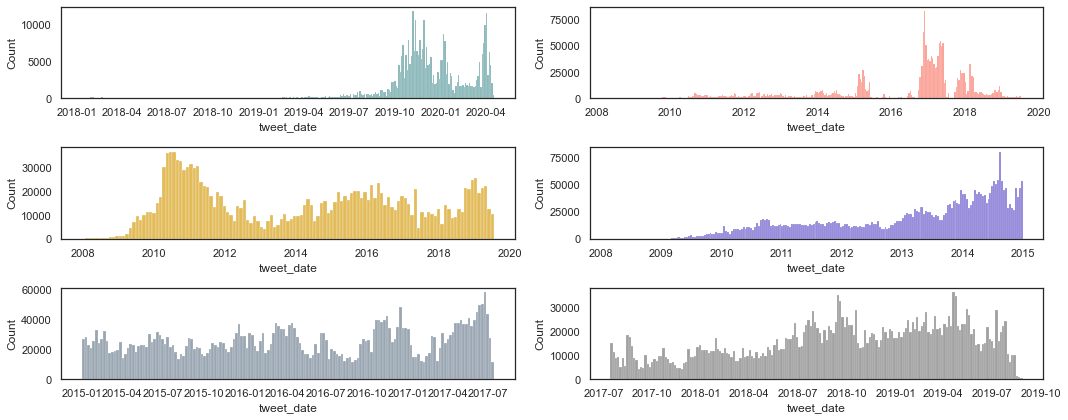

In [16]:
fig, ax = plt.subplots(3,2, sharex=False, figsize=(15,6))

sns.histplot(df0.tweet_date, color='cadetblue', ax=ax[0][0])
sns.histplot(df1.tweet_date, color='salmon', ax=ax[0][1])
sns.histplot(df2.tweet_date, color='goldenrod', ax=ax[1][0])
sns.histplot(df3.tweet_date, color='slateblue', ax=ax[1][1])
sns.histplot(df4.tweet_date, color='lightslategrey', ax=ax[2][0])
sns.histplot(df5.tweet_date, color='gray', ax=ax[2][1])


fig.tight_layout()

fig.show()


In the first dataset, the tweets are mostly concentrated around 2019,  which was when the protest happened, so this might be the most relevant dataset for us. 

#### From now on we focus on this particular dataset. 
We begin with the details about the account creation dates of the users making these tweets. We also label some of the major events during the protests. Dates and events gathered from [wikipedia](https://en.wikipedia.org/wiki/2019%E2%80%932020_Hong_Kong_protests).


#### Account creation dates
The largest increase in accounts happened before the event 'siege of CUHK', [link to wikipedia page on this](https://en.wikipedia.org/wiki/Siege_of_the_Chinese_University_of_Hong_Kong). Here, CUHK refers to Chinese University of Hong Kong. In Nov 2019, Hong Kong police surrounded the university campus with the intent to arrest student protestors, but were met with barricade and Molotov cocktails, which resulted in a violent clash that marked the culmination of the protests. 

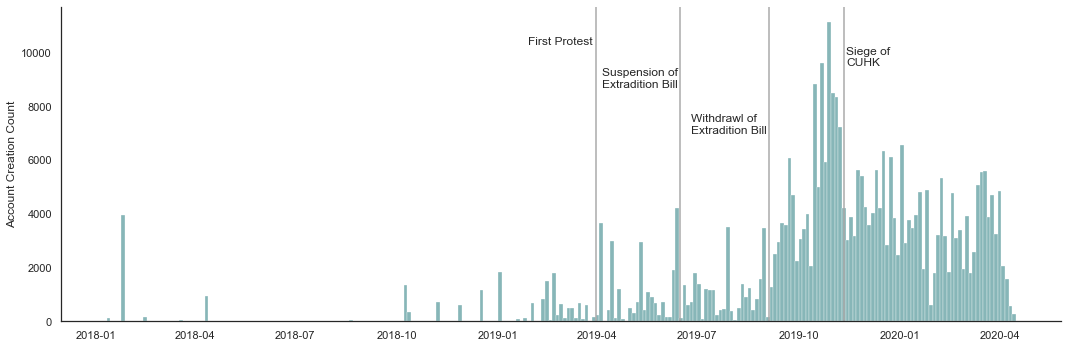

In [17]:
fig, ax = plt.subplots(figsize=(15,5))

sns.histplot(df0.account_creation_date, color='cadetblue')
#ax.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Account Creation Count')
plt.xlabel(None)

plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
ax.annotate('First Protest', xy=(dt.datetime(2019, 1, 28), 10300))

plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 4, 5), 8700))

plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 6, 25), 7000))

plt.axvline(dt.datetime(2019, 11, 11), color='darkgrey')
ax.annotate('Siege of\nCUHK', xy=(dt.datetime(2019, 11, 13), 9500))

fig.tight_layout()

fig.show()


In the above plot we see an uptick of new accounts since the first major protest took place in April 2019.

Next, we look at the number of tweets in 2019 contained in this particular dataset.

In [18]:
df0_19 = df0[df0['tweet_date'].dt.year == 2019]
print("Entry count with years = 2019:", len(df0_19))

Entry count with years = 2019: 208103


#### Daily tweet counts

~200k is a sizable number of tweets. Let's visualize the dates they were being tweeted, along with the labels on some major events during the protests.



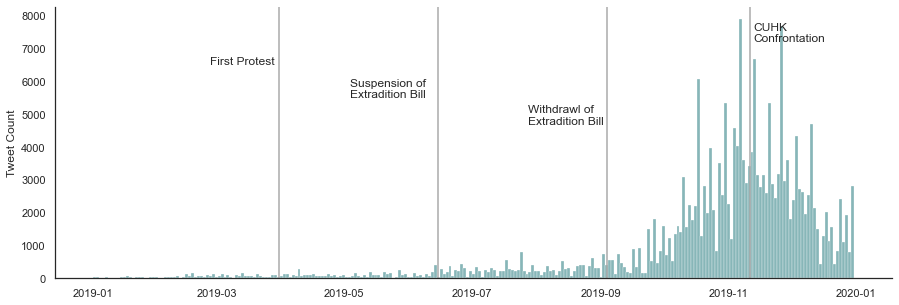

In [19]:
fig, ax = plt.subplots(figsize=(15,5))
sns.histplot(df0_19.tweet_date, color='cadetblue')
#plt.grid(b=None)
#ax.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Tweet Count')
plt.xlabel(None)

plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
ax.annotate('First Protest', xy=(dt.datetime(2019, 2, 26), 6500))

plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 5, 4), 5500))

plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 7, 28), 4700))

plt.axvline(dt.datetime(2019, 11, 11), color='darkgrey')
ax.annotate('CUHK\nConfrontation', xy=(dt.datetime(2019, 11, 13), 7200))

plt.show()

We also create a heat map to display the same data.

In [20]:
df0_19_daily_count = df0_19.groupby('tweet_date').size()

Text(0.1, 0.98, '2019 Daily Tweet Count')

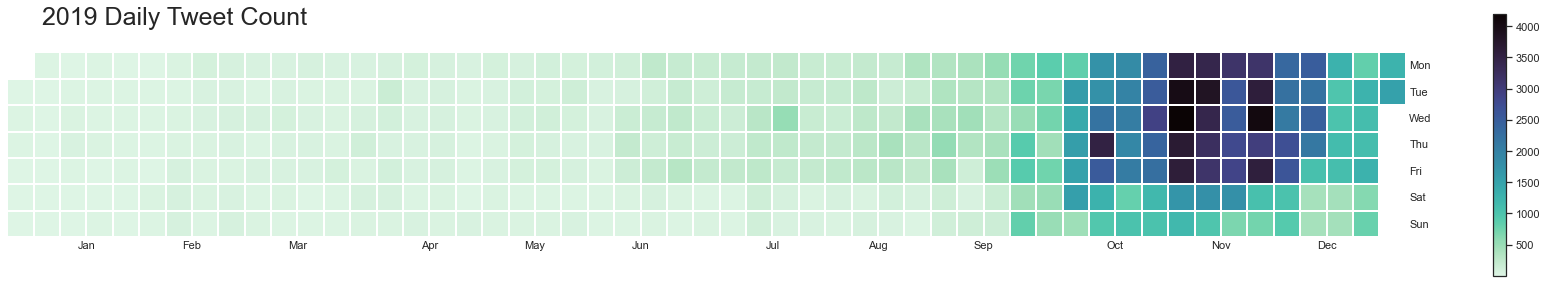

In [21]:
calplot.calplot(df0_19_daily_count,  
                cmap='mako_r', 
                edgecolor=None,
                yearlabels = False,
                #yearlabel_kws={'fontsize':0},
                figsize=(25,4))
plt.suptitle('2019 Daily Tweet Count', fontsize=25, x=0.1)

In this particular dataset, the tweet dates are clustered around October - November 2019, when the violent clashes between police and protestors became more frequent. There are probably common features among the tweets around this time that Twitter used to discover these troll users.

In [22]:
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#fig, ax = plt.subplots(figsize=(18,10))


#cax = calmap.yearplot(df0_19_daily_count, year=2019, cmap='mako_r', fillcolor='grey')
#divider = make_axes_locatable(cax)
#lcax = divider.append_axes("right", size="2%", pad=0.5)
#fig.colorbar(cax.get_children()[1], cax=lcax)

# Tweet Content and Topic Modelling
## Finding the most tweeted topics and vocabularies

We now perform some simple topic modellings and visualization on the tweet contents. Specifically we will focus on tweets that are in Chinese (both traditional or simplified) or English, but before we separate out the languages, wwe will take a quick look at the tweets to see what simple cleaning might need to be done.

As we will see below, in terms of the data, these tweet contents are quite noisy.

In [23]:
df0_19[['tweet_text']].head(15)

,tweet_text
0,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...
4,秋 https://t.co/36ISekYyC9
5,欧冠-国米 第81分钟，埃斯波西托强行突入禁区右翼被胡梅尔斯铲倒，主裁判判罚了点球。但随...
6,Necessity is the mother of invention
7,只要你非常努力，总有一天你会发现，你永远无法拉近你跟有钱人的差距。生活会让你苦上一阵子，等你...
8,https://t.co/SJingEzc2T
9,https://t.co/7G5LiEI4mL
10,这样的天气适合趟在自己的被窝 https://t.co/Gz9x04ZLsS
11,明愛馬鞍山中學發現懷疑炸彈 兩生被捕 學校停課 支持警方深入調查！ #香港選舉 #愛港護港 ...
12,郭文贵和他的乌合之众已日薄西山，气息奄奄，你看他只剩下蹭热度、编谣言、耍嘴炮来苦苦支撑郭媒体...


We will remove tweets that start with 'RT' which are reteeted contents.
<br>We will also remove urls.

In [24]:
df0_19 = df0_19[~df0_19['tweet_text'].str.startswith('RT')]
df0_19['tweet_text'] = df0_19['tweet_text'].str.replace(r'http\S+', '')

df0_19[['tweet_text']].head(10)

,tweet_text
0,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...
4,秋
5,欧冠-国米 第81分钟，埃斯波西托强行突入禁区右翼被胡梅尔斯铲倒，主裁判判罚了点球。但随...
6,Necessity is the mother of invention
7,只要你非常努力，总有一天你会发现，你永远无法拉近你跟有钱人的差距。生活会让你苦上一阵子，等你...
8,
9,
10,这样的天气适合趟在自己的被窝
11,明愛馬鞍山中學發現懷疑炸彈 兩生被捕 學校停課 支持警方深入調查！ #香港選舉 #愛港護港 ...
12,郭文贵和他的乌合之众已日薄西山，气息奄奄，你看他只剩下蹭热度、编谣言、耍嘴炮来苦苦支撑郭媒体...


After replacing urls with blanks, we see some tweets become empty. Let's make a count.

In [25]:
blanks = []
for i, tweet in df0_19['tweet_text'].iteritems():  
    if type(tweet)==str:          
        if tweet.isspace() or tweet == "":         
            blanks.append(i)   
len(blanks)

5750

Since ~5k is a relatively small number, we'll simply remove them, and still left with ~94k tweets.

In [26]:
df0_19.drop(blanks, inplace=True)

In [27]:
print("Total tweet count:", len(df0_19))

Total tweet count: 94260


I'm also interested in how many different accounts are tweeting these 94k tweets.
<br>Since I'm not sure how 'userid', 'user_display_name', and 'user_screen_name' are related to each other, we'll just make a count on all of them.

In [28]:
print("Number of distinct user IDs: ", df0_19['userid'].nunique())
print("Number of distinct display names: ", df0_19['user_display_name'].nunique())
print("Number of distinct user screen names: ", df0_19['user_screen_name'].nunique())

Number of distinct user IDs:  9964
Number of distinct display names:  9964
Number of distinct user screen names:  9964


Seems like they do represent the same thing. Next we will look into the number of tweets in different languages.

In [29]:
df0_19['tweet_language'].value_counts().head(10)

zh     76207
en      6426
ja      5480
ru      2828
und     1710
pt       225
in       206
tr       156
ko       137
de        67
Name: tweet_language, dtype: int64

### English tweets:

Looks like there are a variety of languages going on, but as mentioned before we focus on the Chinese and English ones. We start with the English tweets.

In [30]:
df0_19_en = df0_19[df0_19['tweet_language'] == 'en']
df0_19_en_text = pd.DataFrame(df0_19_en['tweet_text'].copy())


print("# of users tweeting in English:", df0_19_en['user_display_name'].nunique())
print("% of all users: {:0.2f}%".format(100 * df0_19_en['user_display_name'].nunique() / df0_19['user_display_name'].nunique()))
print("# of English tweets:", len(df0_19_en_text))
print("% of all tweets {:0.2f}%:".format(100 * len(df0_19_en_text)/ len(df0_19)))

# of users tweeting in English: 2481
% of all users: 24.90%
# of English tweets: 6426
% of all tweets 6.82%:


In [31]:
df0_19_en_text.head(10)

,tweet_text
6,Necessity is the mother of invention
27,"Want to see the walking dead, but feel a littl..."
61,Love is not a maybe thing. You know when you l...
66,"The purpose of life is to live it out, to expe..."
100,"Love, career and family, are selected item, as..."
104,"From that hour, nobody is proved to have seen ..."
111,"In autumn, most of the leaves have gradually t..."
134,Believer! Storyfinder? Leader of Change?
177,The Origin of Halloween
184,Worrying never did anyone any good


A first glance doesn't seem to tell us anything. For example "The Origin of Halloween", "Worrying never did anyone any good" just sound like generic tweet contents. 

To better understand the tweet contents we will first lemmatize the tweets and then make a wordcloud to display some of the most tweeted words.  

Remark: we have to add certain stopwords to screen out irrevelant contents in the tweets. This is done with string.punctuation and manually adding a few others that we found by trial and error.

In [32]:
stop_words_en = stopwords.words('english')
stop_words_en += list(string.punctuation)
stop_words_en += ['rt', '’', '\'s', '``', '\'\'', '““', 'n\'t', 'amp', 'u' , '']
lemmatizer = WordNetLemmatizer()

def tokenize(tweet_text):
    tokens = word_tokenize(tweet_text)
    tokens = [token.lower() for token in tokens if token.isalpha() and token.lower() not in stop_words_en and len(token) >= 3]
    
    lemmatized =[lemmatizer.lemmatize(token) for token in tokens]
    
    return lemmatized

In [33]:
def make_wordcloud(tweet_col):
    tweet_col = tweet_col.apply(tokenize)
    flat_words = [item for sublist in tweet_col for item in sublist]
    word_freq = FreqDist(flat_words)
    
    top20_word  = [n[0] for n in word_freq.most_common(20)]
    top20_count = [n[1] for n in word_freq.most_common(20)]
    top_20_dict = dict(zip(top20_word, top20_count))
    
    wordcloud = WordCloud(width=1600, height=800, 
                          colormap = 'mako', 
                          background_color = 'white').generate_from_frequencies(top_20_dict)

    plt.figure(figsize=(8,6))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

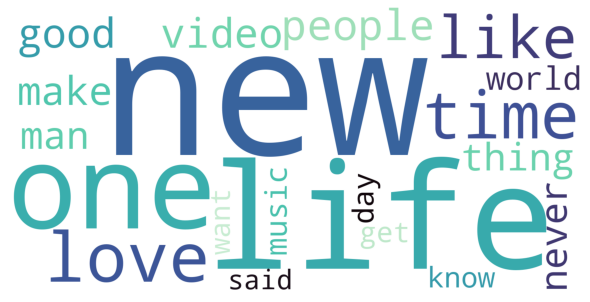

In [34]:
make_wordcloud(df0_19_en_text['tweet_text'])

These words don't seem to follow any specific topics. I am inclined to believe these are just accounts pretending to be genuine users tweeting out mostly innocent contents. 

To zero in on this, let's use TfidfVectorizer and non-negative matrix factorization for a simple topic modelling. In particular we will try to group 10 topics, with the top 5 words for each topic.

In [35]:
def find_topics_words_en(tweet_col, n_components, num_words):
    tfidf = TfidfVectorizer(max_df=0.8, min_df=5, stop_words=stop_words_en)
    dtm = tfidf.fit_transform(tweet_col)


    nmf_model = NMF(n_components=n_components, random_state=2)
    nmf_model.fit(dtm)
    
  
    all_word_list = []
    
    for index, topic in enumerate(nmf_model.components_):
        print(f"The top {num_words} words for topic # {index + 1}")
        word_list = [tfidf.get_feature_names()[i] for i in topic.argsort()[-num_words:]]
        all_word_list.append(word_list)
        print(word_list)
        print("\n")
    
    return all_word_list




In [36]:
all_word_list = find_topics_words_en(df0_19_en_text['tweet_text'], 10, 5)

The top 5 words for topic # 1
['young', 'album', 'ft', 'new', 'video']


The top 5 words for topic # 2
['perfect', 'give', 'know', 'bts_twt', 'love']


The top 5 words for topic # 3
['may', 'make', 'beautiful', 'hope', 'life']


The top 5 words for topic # 4
['miss', 'little', 'morning', 'bad', 'good']


The top 5 words for topic # 5
['coming', 'hello', 'setting', 'twitter', 'myfirsttweet']


The top 5 words for topic # 6
['two', 'thing', 'person', 'world', 'one']


The top 5 words for topic # 7
['lil', 'album', 'ft', 'new', 'music']


The top 5 words for topic # 8
['things', 'money', 'long', 'people', 'time']


The top 5 words for topic # 9
['well', 'kong', 'hong', 'people', 'like']


The top 5 words for topic # 10
['mind', 'say', 'man', 'nothing', 'never']




Some of the relevant topics are starting to emerge: 
<br>In topic # 9 we see keywords such as 'hong kong people'. 

Let's narrow down the number of topics (say, 5 topics) but with more words each topic (10 words).

In [37]:
all_word_list = find_topics_words_en(df0_19_en_text['tweet_text'], 5, 10)

The top 10 words for topic # 1
['remix', 'kid', 'ep', 'young', 'lil', 'album', 'music', 'ft', 'video', 'new']


The top 10 words for topic # 2
['sweet', 'without', 'folly', 'person', 'someone', 'perfect', 'give', 'know', 'bts_twt', 'love']


The top 10 words for topic # 3
['world', 'man', 'make', 'hope', 'never', 'people', 'like', 'time', 'one', 'life']


The top 10 words for topic # 4
['best', 'rest', 'times', 'make', 'miss', 'little', 'morning', 'bad', 'man', 'good']


The top 10 words for topic # 5
['rights', 'first', 'sound', 'hi', 'coming', 'time', 'hello', 'setting', 'twitter', 'myfirsttweet']




Unfortunately it doesn't seem to find anything too useful either.

For latter use we define a function to make wordclouds out of these topics.

In [38]:
def topic_to_wordcloud(all_word_list, tweet_col):
    for i in range(len(all_word_list)):
        word_list  = all_word_list[i]
        count_list = []
        for word in word_list:
            count_list.append(tweet_col.str.count(word).sum())
        
        word_count_dict = dict(zip(word_list, count_list))
        
        wordcloud = WordCloud(width=1600, height=800, 
                          colormap = 'mako', 
                          background_color = 'white').generate_from_frequencies(word_count_dict)

        plt.figure(figsize=(4,2))
        plt.imshow(wordcloud)
        plt.axis("off")
        plt.tight_layout(pad=0)
        plt.show()
            

In [39]:
# topic_to_wordcloud(all_word_list, df0_19_en_text['tweet_text'])

### Chinese tweets:

Now we look at the Chinese tweets, which are the majority in this dataset.

In [40]:
df0_19_zh = df0_19[df0_19['tweet_language'] == 'zh']
df0_19_zh_text = pd.DataFrame(df0_19_zh['tweet_text'].copy())


print("# of users tweeting in Chinese:", df0_19_zh['user_display_name'].nunique())
print("% of all users: {:0.2f}%".format(100 * df0_19_zh['user_display_name'].nunique() / df0_19['user_display_name'].nunique()))
print("# of Chinese tweets:", len(df0_19_zh_text))
print("% of all tweets {:0.2f}%:".format(100 * len(df0_19_zh_text)/ len(df0_19)))

# of users tweeting in Chinese: 9242
% of all users: 92.75%
# of Chinese tweets: 76207
% of all tweets 80.85%:


In [41]:
df0_19_zh_text.head(10)

,tweet_text
0,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...
5,欧冠-国米 第81分钟，埃斯波西托强行突入禁区右翼被胡梅尔斯铲倒，主裁判判罚了点球。但随...
7,只要你非常努力，总有一天你会发现，你永远无法拉近你跟有钱人的差距。生活会让你苦上一阵子，等你...
10,这样的天气适合趟在自己的被窝
11,明愛馬鞍山中學發現懷疑炸彈 兩生被捕 學校停課 支持警方深入調查！ #香港選舉 #愛港護港 ...
12,郭文贵和他的乌合之众已日薄西山，气息奄奄，你看他只剩下蹭热度、编谣言、耍嘴炮来苦苦支撑郭媒体...
15,.这个世界本就邋遢，所以没有什么可怕。每个人都有无法发泄的苦涩，都有无力排解的抑郁，而生活在...
21,無論係泛民派仲係建制派，止暴制亂恢復秩序之路任重而道遠，唔辜負選民嘅支持唔違反一國兩制嘅精神...
23,"骗子郭文贵不知疲倦地搞政治诽谤,讲述离奇故事，不过是一出又一出让人调侃的闹剧罢了。"
24,不是某人使你烦恼，而是你拿某人的言行来烦恼自己。


We will basically repeat the same exploration as above, but for Chinese tweets. 

To perform topic modelling in Chinese, we use [jieba](https://github.com/fxsjy/jieba) to recognize vocabularies in the tweets. I found the list of Chinese stopwords online, but there may be better libraries for this purpose that I am not aware of.

In [42]:
chinese_stopwords = ["、","。","〈","〉","《","》","一","一些","一何","一切","一则","一方面","一旦","一来","一样","一般","一转眼","七","万一","三","上","上下","下","不","不仅","不但","不光","不单","不只","不外乎","不如","不妨","不尽","不尽然","不得","不怕","不惟","不成","不拘","不料","不是","不比","不然","不特","不独","不管","不至于","不若","不论","不过","不问","与","与其","与其说","与否","与此同时","且","且不说","且说","两者","个","个别","中","临","为","为了","为什么","为何","为止","为此","为着","乃","乃至","乃至于","么","之","之一","之所以","之类","乌乎","乎","乘","九","也","也好","也罢","了","二","二来","于","于是","于是乎","云云","云尔","五","些","亦","人","人们","人家","什","什么","什么样","今","介于","仍","仍旧","从","从此","从而","他","他人","他们","他们们","以","以上","以为","以便","以免","以及","以故","以期","以来","以至","以至于","以致","们","任","任何","任凭","会","似的","但","但凡","但是","何","何以","何况","何处","何时","余外","作为","你","你们","使","使得","例如","依","依据","依照","便于","俺","俺们","倘","倘使","倘或","倘然","倘若","借","借傥然","假使","假如","假若","做","像","儿","先不先","光是","全体","全部","八","六","兮","共","关于","关于具体地说","其","其一","其中","其二","其他","其余","其它","其次","具体地说","具体说来","兼之","内","再","再其次","再则","再有","再者","再者说","再说","冒","冲","况且","几","几时","凡","凡是","凭","凭借","出于","出来","分","分别","则","则甚","别","别人","别处","别是","别的","别管","别说","到","前后","前此","前者","加之","加以","即","即令","即使","即便","即如","即或","即若","却","去","又","又及","及","及其","及至","反之","反而","反过来","反过来说","受到","另","另一方面","另外","另悉","只","只当","只怕","只是","只有","只消","只要","只限","叫","叮咚","可","可以","可是","可见","各","各个","各位","各种","各自","同","同时","后","后者","向","向使","向着","吓","吗","否则","吧","吧哒","含","吱","呀","呃","呕","呗","呜","呜呼","呢","呵","呵呵","呸","呼哧","咋","和","咚","咦","咧","咱","咱们","咳","哇","哈","哈哈","哉","哎","哎呀","哎哟","哗","哟","哦","哩","哪","哪个","哪些","哪儿","哪天","哪年","哪怕","哪样","哪边","哪里","哼","哼唷","唉","唯有","啊","啐","啥","啦","啪达","啷当","喂","喏","喔唷","喽","嗡","嗡嗡","嗬","嗯","嗳","嘎","嘎登","嘘","嘛","嘻","嘿","嘿嘿","四","因","因为","因了","因此","因着","因而","固然","在","在下","在于","地","基于","处在","多","多么","多少","大","大家","她","她们","好","如","如上","如上所述","如下","如何","如其","如同","如是","如果","如此","如若","始而","孰料","孰知","宁","宁可","宁愿","宁肯","它","它们","对","对于","对待","对方","对比","将","小","尔","尔后","尔尔","尚且","就","就是","就是了","就是说","就算","就要","尽","尽管","尽管如此","岂但","己","已","已矣","巴","巴巴","年","并","并且","庶乎","庶几","开外","开始","归","归齐","当","当地","当然","当着","彼","彼时","彼此","往","待","很","得","得了","怎","怎么","怎么办","怎么样","怎奈","怎样","总之","总的来看","总的来说","总的说来","总而言之","恰恰相反","您","惟其","慢说","我","我们","或","或则","或是","或曰","或者","截至","所","所以","所在","所幸","所有","才","才能","打","打从","把","抑或","拿","按","按照","换句话说","换言之","据","据此","接着","故","故此","故而","旁人","无","无宁","无论","既","既往","既是","既然","日","时","时候","是","是以","是的","更","曾","替","替代","最","月","有","有些","有关","有及","有时","有的","望","朝","朝着","本","本人","本地","本着","本身","来","来着","来自","来说","极了","果然","果真","某","某个","某些","某某","根据","欤","正值","正如","正巧","正是","此","此地","此处","此外","此时","此次","此间","毋宁","每","每当","比","比及","比如","比方","没奈何","沿","沿着","漫说","焉","然则","然后","然而","照","照着","犹且","犹自","甚且","甚么","甚或","甚而","甚至","甚至于","用","用来","由","由于","由是","由此","由此可见","的","的确","的话","直到","相对而言","省得","看","眨眼","着","着呢","矣","矣乎","矣哉","离","秒","竟而","第","等","等到","等等","简言之","管","类如","紧接着","纵","纵令","纵使","纵然","经","经过","结果","给","继之","继后","继而","综上所述","罢了","者","而","而且","而况","而后","而外","而已","而是","而言","能","能否","腾","自","自个儿","自从","自各儿","自后","自家","自己","自打","自身","至","至于","至今","至若","致","般的","若","若夫","若是","若果","若非","莫不然","莫如","莫若","虽","虽则","虽然","虽说","被","要","要不","要不是","要不然","要么","要是","譬喻","譬如","让","许多","论","设使","设或","设若","诚如","诚然","该","说","说来","请","诸","诸位","诸如","谁","谁人","谁料","谁知","贼死","赖以","赶","起","起见","趁","趁着","越是","距","跟","较","较之","边","过","还","还是","还有","还要","这","这一来","这个","这么","这么些","这么样","这么点儿","这些","这会儿","这儿","这就是说","这时","这样","这次","这般","这边","这里","进而","连","连同","逐步","通过","遵循","遵照","那","那个","那么","那么些","那么样","那些","那会儿","那儿","那时","那样","那般","那边","那里","都","鄙人","鉴于","针对","阿","除","除了","除外","除开","除此之外","除非","随","随后","随时","随着","难道说","零","非","非但","非徒","非特","非独","靠","顺","顺着","首先","︿","！","＃","＄","％","＆","（","）","＊","＋","，","０","１","２","３","４","５","６","７","８","９","：","；","＜","＞","？","＠","［","］","｛","｜","｝","～","￥"]

def find_topics_words_zh(tweet_text, n_components, num_words):
    tfidf = TfidfVectorizer(max_df=0.9, min_df=5, tokenizer=jieba.cut, lowercase=False, stop_words=chinese_stopwords)
    dtm = tfidf.fit_transform(tweet_text['tweet_text'])


    nmf_model = NMF(n_components=n_components, random_state=2)
    nmf_model.fit(dtm)

  
    all_word_list = []
    
    for index, topic in enumerate(nmf_model.components_):
        print(f"The top {num_words} words for topic # {index + 1}")
        word_list = [tfidf.get_feature_names()[i] for i in topic.argsort()[-num_words:]]
        all_word_list.append(word_list)
        print(word_list)
        print("\n")
    
    return all_word_list    

    
    

In [43]:
find_topics_words_zh(df0_19_zh_text, 10, 5)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\ivanc\AppData\Local\Temp\jieba.cache
Loading model cost 0.744 seconds.
Prefix dict has been built succesfully.


The top 5 words for topic # 1
['=', 'YouTube', '_', '@', ' ']


The top 5 words for topic # 2
['」', '係', '哋', '唔', '嘅']


The top 5 words for topic # 3
['「', '\xa0', '香港', ' ', '#']


The top 5 words for topic # 4
['文贵', ' ', '@', '=', '+']


The top 5 words for topic # 5
['加油', '暴力', '支持', '警察', '香港']


The top 5 words for topic # 6
['基金', '文贵', '中国', '”', '“']


The top 5 words for topic # 7
['.', ' ', '\u3000', '—', '\n']


The top 5 words for topic # 8
['文贵', '骗子', '一个', '班农', '郭文贵']


The top 5 words for topic # 9
['必须', '支持', '@', '严惩', '暴徒']


The top 5 words for topic # 10
['小人', '—', '@', '李一平', 'liyiping1911']




[['=', 'YouTube', '_', '@', ' '],
 ['」', '係', '哋', '唔', '嘅'],
 ['「', '\xa0', '香港', ' ', '#'],
 ['文贵', ' ', '@', '=', '+'],
 ['加油', '暴力', '支持', '警察', '香港'],
 ['基金', '文贵', '中国', '”', '“'],
 ['.', ' ', '\u3000', '—', '\n'],
 ['文贵', '骗子', '一个', '班农', '郭文贵'],
 ['必须', '支持', '@', '严惩', '暴徒'],
 ['小人', '—', '@', '李一平', 'liyiping1911']]

First result isn't great, there are irevelant symbols, Chinese punctuations, and strings such as '@', '」', '\u3000', so we will have to manually add those to the list of stopwords.

Although, some interesting words/topics appeared:  

#### Top 5 words for topic # 5
['加油', '暴力', '支持', '警察', '香港']
<br>[add oil, violence, support, police, Hong Kong]

#### Top 5 words for topic # 9
['必须', '支持', '@', '严惩', '暴徒']
<br>[must, support, severe punishment, violent thug (referring to the protestors)]

We will now update the stopwords list, then narrow it down to 5 topics, 10 words each topic.

In [44]:
chinese_stopwords = ['有', '没有', '會', '對', 'RT', ':', '\u3000', '.', '"', '!', ',','?','為', '佢', '喺', '唔', '」', '「', '哋', '係', '嘅',  '\xa0', '所谓', '一个', '\n', '=', '@', '+', '”', '“', '…', '#',  "、","。","〈","〉","《","》","一","一些","一何","一切","一则","一方面","一旦","一来","一样","一般","一转眼","七","万一","三","上","上下","下","不","不仅","不但","不光","不单","不只","不外乎","不如","不妨","不尽","不尽然","不得","不怕","不惟","不成","不拘","不料","不是","不比","不然","不特","不独","不管","不至于","不若","不论","不过","不问","与","与其","与其说","与否","与此同时","且","且不说","且说","两者","个","个别","中","临","为","为了","为什么","为何","为止","为此","为着","乃","乃至","乃至于","么","之","之一","之所以","之类","乌乎","乎","乘","九","也","也好","也罢","了","二","二来","于","于是","于是乎","云云","云尔","五","些","亦","人","人们","人家","什","什么","什么样","今","介于","仍","仍旧","从","从此","从而","他","他人","他们","他们们","以","以上","以为","以便","以免","以及","以故","以期","以来","以至","以至于","以致","们","任","任何","任凭","会","似的","但","但凡","但是","何","何以","何况","何处","何时","余外","作为","你","你们","使","使得","例如","依","依据","依照","便于","俺","俺们","倘","倘使","倘或","倘然","倘若","借","借傥然","假使","假如","假若","做","像","儿","先不先","光是","全体","全部","八","六","兮","共","关于","关于具体地说","其","其一","其中","其二","其他","其余","其它","其次","具体地说","具体说来","兼之","内","再","再其次","再则","再有","再者","再者说","再说","冒","冲","况且","几","几时","凡","凡是","凭","凭借","出于","出来","分","分别","则","则甚","别","别人","别处","别是","别的","别管","别说","到","前后","前此","前者","加之","加以","即","即令","即使","即便","即如","即或","即若","却","去","又","又及","及","及其","及至","反之","反而","反过来","反过来说","受到","另","另一方面","另外","另悉","只","只当","只怕","只是","只有","只消","只要","只限","叫","叮咚","可","可以","可是","可见","各","各个","各位","各种","各自","同","同时","后","后者","向","向使","向着","吓","吗","否则","吧","吧哒","含","吱","呀","呃","呕","呗","呜","呜呼","呢","呵","呵呵","呸","呼哧","咋","和","咚","咦","咧","咱","咱们","咳","哇","哈","哈哈","哉","哎","哎呀","哎哟","哗","哟","哦","哩","哪","哪个","哪些","哪儿","哪天","哪年","哪怕","哪样","哪边","哪里","哼","哼唷","唉","唯有","啊","啐","啥","啦","啪达","啷当","喂","喏","喔唷","喽","嗡","嗡嗡","嗬","嗯","嗳","嘎","嘎登","嘘","嘛","嘻","嘿","嘿嘿","四","因","因为","因了","因此","因着","因而","固然","在","在下","在于","地","基于","处在","多","多么","多少","大","大家","她","她们","好","如","如上","如上所述","如下","如何","如其","如同","如是","如果","如此","如若","始而","孰料","孰知","宁","宁可","宁愿","宁肯","它","它们","对","对于","对待","对方","对比","将","小","尔","尔后","尔尔","尚且","就","就是","就是了","就是说","就算","就要","尽","尽管","尽管如此","岂但","己","已","已矣","巴","巴巴","年","并","并且","庶乎","庶几","开外","开始","归","归齐","当","当地","当然","当着","彼","彼时","彼此","往","待","很","得","得了","怎","怎么","怎么办","怎么样","怎奈","怎样","总之","总的来看","总的来说","总的说来","总而言之","恰恰相反","您","惟其","慢说","我","我们","或","或则","或是","或曰","或者","截至","所","所以","所在","所幸","所有","才","才能","打","打从","把","抑或","拿","按","按照","换句话说","换言之","据","据此","接着","故","故此","故而","旁人","无","无宁","无论","既","既往","既是","既然","日","时","时候","是","是以","是的","更","曾","替","替代","最","月","有","有些","有关","有及","有时","有的","望","朝","朝着","本","本人","本地","本着","本身","来","来着","来自","来说","极了","果然","果真","某","某个","某些","某某","根据","欤","正值","正如","正巧","正是","此","此地","此处","此外","此时","此次","此间","毋宁","每","每当","比","比及","比如","比方","没奈何","沿","沿着","漫说","焉","然则","然后","然而","照","照着","犹且","犹自","甚且","甚么","甚或","甚而","甚至","甚至于","用","用来","由","由于","由是","由此","由此可见","的","的确","的话","直到","相对而言","省得","看","眨眼","着","着呢","矣","矣乎","矣哉","离","秒","竟而","第","等","等到","等等","简言之","管","类如","紧接着","纵","纵令","纵使","纵然","经","经过","结果","给","继之","继后","继而","综上所述","罢了","者","而","而且","而况","而后","而外","而已","而是","而言","能","能否","腾","自","自个儿","自从","自各儿","自后","自家","自己","自打","自身","至","至于","至今","至若","致","般的","若","若夫","若是","若果","若非","莫不然","莫如","莫若","虽","虽则","虽然","虽说","被","要","要不","要不是","要不然","要么","要是","譬喻","譬如","让","许多","论","设使","设或","设若","诚如","诚然","该","说","说来","请","诸","诸位","诸如","谁","谁人","谁料","谁知","贼死","赖以","赶","起","起见","趁","趁着","越是","距","跟","较","较之","边","过","还","还是","还有","还要","这","这一来","这个","这么","这么些","这么样","这么点儿","这些","这会儿","这儿","这就是说","这时","这样","这次","这般","这边","这里","进而","连","连同","逐步","通过","遵循","遵照","那","那个","那么","那么些","那么样","那些","那会儿","那儿","那时","那样","那般","那边","那里","都","鄙人","鉴于","针对","阿","除","除了","除外","除开","除此之外","除非","随","随后","随时","随着","难道说","零","非","非但","非徒","非特","非独","靠","顺","顺着","首先","︿","！","＃","＄","％","＆","（","）","＊","＋","，","０","１","２","３","４","５","６","７","８","９","：","；","＜","＞","？","＠","［","］","｛","｜","｝","～","￥"]

In [45]:
all_word_list = find_topics_words_zh(df0_19_zh_text, 5, 10)

The top 10 words for topic # 1
['秩序', '守护', '法治', '加油', '止暴', ' ', '暴力', '支持', '警察', '香港']


The top 10 words for topic # 2
['文贵', 'Alston', 'Kwan', 'to', 'the', 'is', '-', 'YouTube', '_', ' ']


The top 10 words for topic # 3
['美国', '爆料', '基金', '已经', ' ', '郭', '骗子', '文贵', '班农', '郭文贵']


The top 10 words for topic # 4
['万维', '大师', '真', '李', '-', '伪君子', '小人', '李一平', '—', 'liyiping1911']


The top 10 words for topic # 5
['行为', '蒙面', '港警', '嚴懲', ' ', '法律', '必须', '支持', '严惩', '暴徒']




#### The top 10 words for topic # 1
['秩序', '守护', '法治', '加油', '止暴', ' ', '暴力', '支持', '警察', '香港']
<br>[order, protect, rule of law, add oil, stop violence, violence, support, police, Hong Kong ]

#### The top 10 words for topic # 5
['行为', '蒙面', '港警', '嚴懲', ' ', '法律', '必须', '支持', '严惩', '暴徒']
<br>[behavior, masked, HK police, severe punishment, law, must, support, severe punishment, violent thug (referring to the protestors)]

When I tried making a wordcloud out of these words I quickly ran into a challenge: in Hong Kong (and Taiwan), the written language is traditional Chinese, while in mainland China simplified Chinese is used. The two Chinese require different fonts, but there aren't many that could display both properly. The only one that I found that work for both simultanously is NotoSansCJK-Regular.ttc.

In [46]:
font_path = "NotoSansCJK-Regular.ttc"

def topic_to_wordcloud_zh(all_word_list, tweet_col):
#    for i in range(len(all_word_list)):
    word_list  = [word for sublist in all_word_list for word in sublist]
    count_list = []
    for word in word_list:
        count_list.append(tweet_col.str.count(word).sum())
        
    word_count_dict = dict(zip(word_list, count_list))
        
    wordcloud = WordCloud(font_path= font_path, width=1600, height=800, 
                        colormap = 'mako', 
                        background_color = 'white').generate_from_frequencies(word_count_dict)

    plt.figure(figsize=(8,4))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()
            

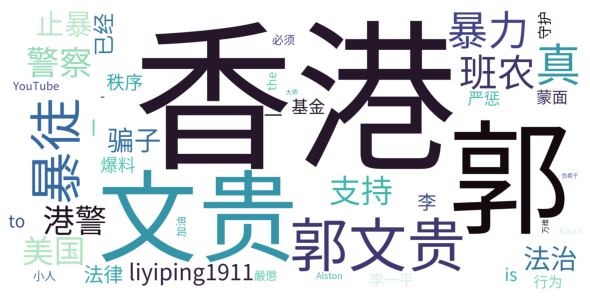

In [47]:
topic_to_wordcloud_zh(all_word_list, df0_19_zh_text['tweet_text'])

### Concluding remark:

In this notebook we have only used the first dataset for a quick exploration, already we were able to extract some interesting information. In Part II we will comebine the datasets and perform similar explorations for a more detailed understanding of these tweets.